# Feedforward Neural Network From Scratch
Ferran Estrella Serra

# Part 1: Neural Network Manually

Here we include the computations used for the first part.

In [273]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### 1. Initial Configuration

In [274]:
# We randomly select a single observation to illustrate the training process
adm = pd.read_csv("Admissions.csv")
np.random.seed(101)
sample=adm.sample(n=1)
X = np.array(sample.iloc[:, 1:3]).flatten()
y_real = 1
sample

,admit,gre,gpa,rank
38,1,500,3.13,2


In [275]:
# We randomly initialize the parameters of the model
np.random.seed(101)
w=np.random.uniform(low=-0.2, high=0.2, size=6)
np.random.seed(101)
b=np.random.uniform(low=-0.05, high=0.05, size=3)
eta = 0.01 # learning rate

W1 = w[0:4].reshape(2, 2) 
b1 = b[0:2]
W2 = w[4:6]
b2 = b[2]

print(W1)
print(b1)
print(W2)
print(b2)

[[ 0.00655945  0.02826703]
 [-0.18861031 -0.13139134]]
[0.00163986 0.00706676]
[0.07411079 0.13355875]
-0.047152577352190306


### 2. Iterations

In [276]:
# Activation function
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_der(a): return a * (1 - a)

In [ ]:
print("--- ITERATION 1 ---")
# Forward
z1 = np.dot(W1, X) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
y_pred = sigmoid(z2)
print(f"Prediction: {y_pred:.4f} | Loss: {-np.log(y_pred):.4f}")

# Backprop
delta_2 = y_pred - y_real
delta_1 = W2*delta_2* sigmoid_der(a1)

# Update
W2n = W2 - eta * (delta_2 * a1)
b2n = b2 - eta * delta_2
W1n = W1 - eta * np.dot(delta_1, X)
b1n = b1 - eta * delta_1

print(f"New weights W^(2):\n{W2n}")
print(f"New weights W^(1):\n{W1n}")
print(f"New bias b^(2):\n{b2n}")
print(f"New bias b^(1):\n{b1n}")

--- ITERATION 1 ---
Prediction: 0.5061 | Loss: 0.6810
New weights W^(2):
[0.07888534 0.13355875]
New weights W^(1):
[[ 0.01244238  0.03414997]
 [-0.18272738 -0.12550841]]
New bias b^(2):
-0.04221380910784753
New bias b^(1):
[0.00165163 0.00706676]


In [278]:
print("\n--- ITERATION 2 ---")
z1n = np.dot(W1n, X) + b1n
a1n = sigmoid(z1n)
z2n = np.dot(a1n, W2n) + b2n
y_pred = sigmoid(z2n)
print(f"Prediction: {y_pred:.4f} | Loss: {-np.log(y_pred):.4f}")


--- ITERATION 2 ---
Prediction: 0.5091 | Loss: 0.6750


# Part 2: Full Neural Network Training

We implement the full neural network training.

## 1. Data Processing

We process the Admissions dataset for use in the neural network.

### 1.1 Data Loading

In [279]:
# Data loading
df = pd.read_csv("Admissions.csv")                           
print(df.head())
# We convert the 'rank' column into 4 separate One-Hot Encoded columns, since it is a categorical variable with 4 categories (1, 2, 3, 4).
df = pd.get_dummies(df, columns=['rank'], dtype=int)

   admit  gre   gpa  rank
0      0  380  3.61     3
1      1  660  3.67     3
2      1  800  4.00     1
3      1  640  3.19     4
4      0  520  2.93     4


In [280]:
# Dataset verification: We check the dataset to make sure no data is missing and check the class labels
def verify_dataset(data):
  #if any of the rows have missing value return datas missing
  data_found = 1
  for each_column in data.columns:
    if data[each_column].isnull().any():
            print("Data missing in Column " + each_column)
            #if any rows are not missing return Dataset is complete. No missing value
            quit()
    if data_found == 1:
        print("Dataset is complete. No missing values. Ok")
    return

verify_dataset(df)

Dataset is complete. No missing values. Ok


### 1.2 Data Splitting

In [281]:
# Test-training split function
def split_dataset_test_train(data,train_size):
  data = data.sample(frac=1, random_state=1301).reset_index(drop=True) # Random sampling for a FIXED SEED
  training_data = data.iloc[:int(train_size * len(data))].reset_index(drop=True)
  testing_data = data.iloc[int(train_size * len(data)):].reset_index(drop=True)
  return [training_data, testing_data]

In [282]:
# We split the dataset into a training set and a test set
df_split = split_dataset_test_train(df, 0.75) 
df_train = df_split[0]
df_test= df_split[1]

# Explanatory variables 
x_train_unnorm = df_train.iloc[:, 1:4].to_numpy()
x_test_unnorm = df_test.iloc[:, 1:4].to_numpy()
# Binary response variable
y_train = df_train.iloc[:, 0:1].to_numpy()
y_test  = df_test.iloc[:, 0:1].to_numpy()

### 1.3 Data (column-wise) Standarization

In [283]:
# Explanatory variables
x_train_unnorm = df_train.to_numpy()[:, 1:] 
x_test_unnorm = df_test.to_numpy()[:, 1:]

# Calculate mean and std for GRE and GPA (the first two columns of x)
mean_train = np.mean(x_train_unnorm[:, 0:2], axis=0)
std_train = np.std(x_train_unnorm[:, 0:2], axis=0)
std_train[std_train == 0] = 1 

x_train = x_train_unnorm.copy()
x_test = x_test_unnorm.copy()

# We standardize the GRE and GPA features using the mean and std from the training set
x_train[:, 0:2] = (x_train[:, 0:2]-mean_train) /std_train
x_test[:, 0:2] = (x_test[:, 0:2]-mean_train) / std_train

## 2. Neural Network Architecture

We present the Feedforward Neural Network (FNN) architecture and the functions used for training and prediction. We consider a shallow FNN with 2 hidden neurons and a single output neuron for classification.

### 2.1 Activations and Loss

All neurons in the FNN use the sigmoid function as activation function: 

In [284]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

And the loss function is the binary cross-entropy function: 

In [285]:
def binary_cross_entropy(y_true, y_pred, eps=1e-15):
    
    # Clipping predictions to avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)

    loss = -np.mean(y_true * np.log(y_pred)+(1 - y_true) * np.log(1 - y_pred))

    return loss

### 2.2 Parameter Initialization

We randomly initialize the parameter values using the following function:

In [286]:
# Function to randomly initialize the network parameters (weights and biases)
def initialize_network(input_size, hidden_size, output_size):
    W1 = 0.2 * (2*np.random.random((input_size, hidden_size)) - 1)  
    W2 = 0.2 * (2*np.random.random((hidden_size, output_size)) - 1)   
    b1 = 0.05 * (2*np.random.random((1, hidden_size)) - 1)     
    b2 = 0.05 * (2*np.random.random((1, output_size)) - 1)  
    return [W1, b1, W2, b2]

### 2.3 Forward Propagation

We perform forward propagation through the network using the following function:

In [287]:
# Function for calculating the activations during forward propagation
def forward_propagation(X, W1, b1, W2, b2): # Here, X is in general a matrix whose rows are different observations (explanatory variables). 
                                            # We (implicitly) use NumPy broadcasting for these expressions to work for such structure in X.
    Z_h = np.dot(X, W1) + b1
    A_h = sigmoid(Z_h)
    Z_o = np.dot(A_h, W2) + b2
    A_o = sigmoid(Z_o)

    return A_h, A_o

### 2.4 Backpropagation

We perform backpropagation through the network using the following function:

In [288]:
# Function for calculating the delta values in the hidden and output layers during backpropagation
def backpropagation(Y, A_h, A_o, W2):
    # Output layer error
    delta_o = (A_o - Y) / Y.shape[0] # This expression is valid if sigmoid activation and cross-entropy loss are assumed (and we average by the batch size) 

    # Hidden layer error
    delta_h1 = np.dot(delta_o, W2.T) 
    delta_h = delta_h1 * A_h*(1-A_h)

    return delta_o, delta_h

Using the deltas computed by the previous function, we update the weights of the FNN during a training iteration. The following function implements a gradient descent update with a fixed learning rate:

In [289]:
def update_weights(X, A_h, delta_o, delta_h, W1, b1, W2, b2, learning_rate):
    W2 = W2 - learning_rate * np.dot(A_h.T, delta_o)
    b2 = b2 - learning_rate * np.sum(delta_o, axis=0)

    W1 = W1 - learning_rate * np.dot(X.T, delta_h)
    b1 = b1 - learning_rate * np.sum(delta_h, axis=0)
    return W1, b1, W2, b2

### 2.5 Training Iteration

We train the network using mini-batch stochastic gradient descent. At each epoch, the training data are randomly shuffled and partitioned into mini-batches. The network parameters are then updated sequentially after backpropagating the loss over each mini-batch. We use early stopping (checkpointing) to save the parameters of the network with the lowest associated validation loss (over an epoch).

In [290]:
def train_neural_network(X_train, Y_train, X_test, Y_test, epochs, learning_rate, batch_size, params):
    W1, b1, W2, b2 = params
    num_samples = X_train.shape[0]
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    loss_history = []
    val_loss_history = []
    
    # Initialize "Best" values for checkpointing (i.e. early stopping)
    best_val_loss = float('inf') 
    best_params = [W1.copy(), b1.copy(), W2.copy(), b2.copy()]

    for epoch in range(epochs):
        # sample a random batch
        indices = np.random.permutation(num_samples)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train[indices]

        for batch_idx in range(num_batches):
            batch_start = batch_idx * batch_size
            batch_end = min(batch_start + batch_size, num_samples)
            
            X_batch = X_shuffled[batch_start:batch_end]
            Y_batch = Y_shuffled[batch_start:batch_end]

            # Forward Propagation
            A_h, A_o = forward_propagation(X_batch, W1, b1, W2, b2)

            # Backpropagation
            delta_o, delta_h = backpropagation(Y_batch, A_h, A_o, W2)

            # Weight update
            W1, b1, W2, b2 = update_weights(X_batch, A_h, delta_o, delta_h, W1, b1, W2, b2, learning_rate)

        
        # Training Loss for the considered epoch 
        _, A_o_train = forward_propagation(X_train, W1, b1, W2, b2)
        train_loss = binary_cross_entropy(Y_train, A_o_train, eps=1e-9)
        loss_history.append(train_loss)
        
        # Test Loss
        _, A_o_test = forward_propagation(X_test, W1, b1, W2, b2)
        val_loss = binary_cross_entropy(Y_test, A_o_test, eps=1e-9)
        val_loss_history.append(val_loss)
        
        # checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = [W1.copy(), b1.copy(), W2.copy(), b2.copy()]
 
    return best_params, loss_history, val_loss_history

### 2.6 Training Metrics

We include metrics to evaluate the training.

In [291]:
# Function for plotting the training and test loss over epochs
def loss_plot(loss_history, val_loss_history):
    # Plot both training and test loss
    plt.plot(loss_history, label="Training Loss")
    plt.plot(val_loss_history, label="Test Loss")

    # Add labels and title
    plt.xlabel("Epochs")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title("Training and Test Loss over Time")

    # Add a legend so we know which line is which
    plt.legend()

    # Display the plot
    plt.show()

In [292]:
# Function for evaluating the model on the test set using the trained model (classification task)
def evaluation(params, tst_set):
    w0, bh, w1, bo = params

    zh = np.dot(tst_set, w0) + bh
    layer1 = sigmoid(zh)

    zo = np.dot(layer1, w1) + bo
    layer2 = sigmoid(zo)

    return (layer2 > 0.5).astype(int)

In [293]:
# Function to obtain the confusion matrix , accuracy, sensitivity and specificity of the model on the test set
from matplotlib.colors import ListedColormap

def confusion_matrix_and_metrics(trainedNet, x_test, y_test):
    y_pred = evaluation(trainedNet, x_test)
    y_pred = y_pred.reshape(-1)
    y_actual = y_test.reshape(-1)

    # confusion matrix
    cm = pd.crosstab(y_actual, y_pred).to_numpy()
    print("Confusion Matrix:")
    print(cm)

    accuracy_cm = np.trace(cm) / np.sum(cm)
    print(f"Test Accuracy: {accuracy_cm * 100:.2f}%")

    if len(np.unique(y_pred)) == 1:
        print(f"The model has learned to always predict the same class: {np.unique(y_pred)[0]}")
    else:
        tn = cm[0, 0]  # True negatives
        fp = cm[0, 1]  # False positives
        fn = cm[1, 0]  # False negatives
        tp = cm[1, 1]  # True positives

        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)

        print(f"Sensitivity/ Recall (True Positive Rate): {sensitivity * 100:.2f}%")
        print(f"Specificity (True Negative Rate): {specificity * 100:.2f}%")

        # Normalize across rows for the heatmap visualization
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        
        df_cm = pd.DataFrame(
            cm_norm,
            index=['Not admitted', 'Admitted'],
            columns=['Not admitted', 'Admitted']
        )

        plt.figure(figsize=(6,6))
        sns.heatmap(
            df_cm,
            cbar=False,
            annot=True,
            cmap=ListedColormap(['white']),
            linewidths=0.5,
            fmt=".2f" 
        )
        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.show()

## 3. Neural Network Training

We train the neural network using the Admissions dataset.

### 3.1 Bivariate Explanatory Variables

We consider only the 2 first explanatory variables.

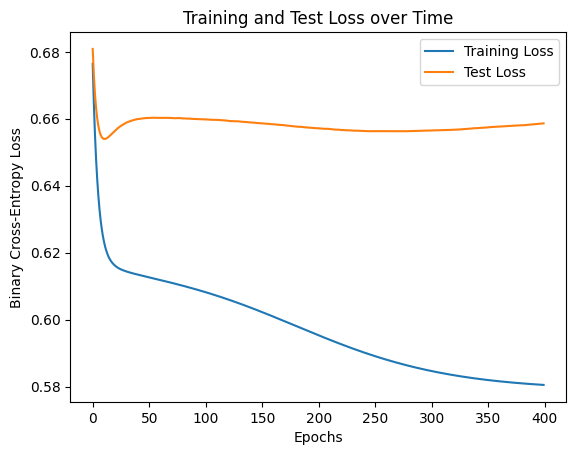

Confusion Matrix:
[[64]
 [36]]
Test Accuracy: 64.00%
The model has learned to always predict the same class: 0


In [294]:
x_train_bi = x_train[:, 0:2]
x_test_bi = x_test[:, 0:2]


np.random.seed(1301)
initial_params = initialize_network(input_size=2, hidden_size=2, output_size=1)
trainedNet, loss_history, val_loss_history = train_neural_network (X_train=x_train_bi, Y_train=y_train, X_test=x_test_bi, Y_test=y_test, 
                                  epochs=400, learning_rate=0.01, batch_size=10,
                                  params=initial_params)
loss_plot(loss_history, val_loss_history)
confusion_matrix_and_metrics(trainedNet, x_test_bi, y_test)

### 3.1 Trivariate Explanatory Variables

We consider all the available explanatory variables.

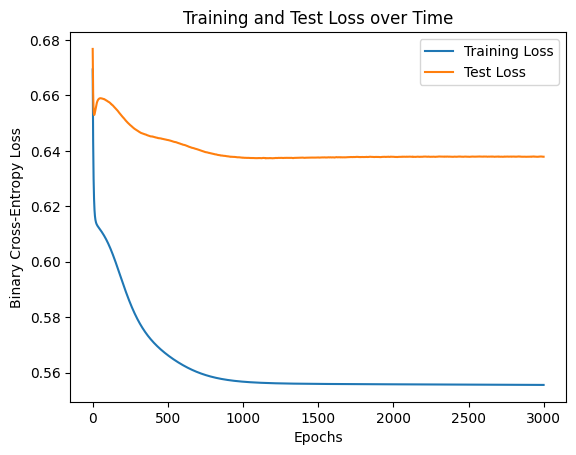

Confusion Matrix:
[[60  4]
 [27  9]]
Test Accuracy: 69.00%
Sensitivity/ Recall (True Positive Rate): 25.00%
Specificity (True Negative Rate): 93.75%


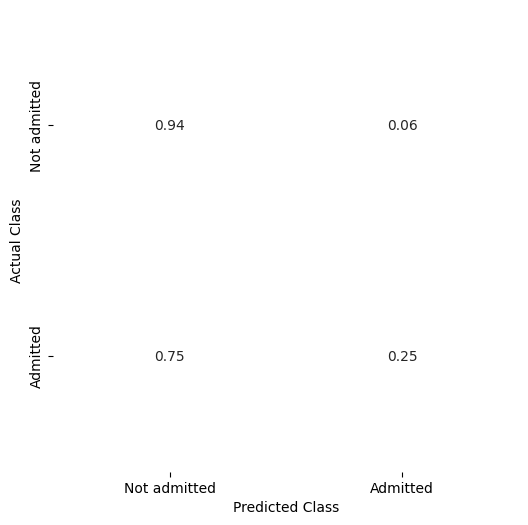

In [295]:
np.random.seed(1301)
initial_params = initialize_network(input_size=6, hidden_size=2, output_size=1)
trainedNet, loss_history, val_loss_history = train_neural_network (X_train=x_train, Y_train=y_train, X_test=x_test, Y_test=y_test, 
                                  epochs=3000, learning_rate=0.01, batch_size=10,
                                  params=initial_params)
loss_plot(loss_history, val_loss_history)
confusion_matrix_and_metrics(trainedNet, x_test, y_test)

## 4 Conclusions

1) For only 2 explanatory variables (GRE and GPA), the FNN learns to always output the same class 0 (“not admitted”) with an accuracy of 64%. This is due to the fact that this class is dominant in the dataset, and since the network does not extract meaningful structure from the input variables, it simply outputs the most probable class.
2) When a third explanatory variable is included (rank), the accuracy increases to 69%. Now, the network begins to exploit information from the input features and no longer predicts a single class. Specificity is high (93.75%), indicating that most “not admitted” cases are correctly identified. However, sensitivity is low (25%), meaning that many “admitted” cases are still misclassified as “not admitted”. The main improvement over the two-variable case is that the model is now able to correctly identify at least some admitted cases.
3) The dataset is relatively noisy for this classification task, as admission decisions depend on additional relevant variables (e.g. letters of recommendation, interviews, etc.). Access to such variables would likely improve model performance.